## Modeling
In this notebook I test out different models and how they work on the dataset.

In [1]:
import pandas as pd

import numpy as np

# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..'))

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm
import script.anomaly_detection as ad

In [3]:
# load in the data
names = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
data = dp.load_split_data(names, 'dataset1')
X_train, X_val, X_test, y_train, y_val, y_test = data['X_train'], data['X_val'], data['X_test'], data['y_train'], data['y_val'], data['y_test']

Load data with base name: dataset1


In [4]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Anomaly,Flow rate (Mean)_rolling_mean_10,...,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_std_10,Anomaly_rolling_min_10,Anomaly_rolling_max_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,3.769735,3.891036,3.855507,3.851978,-5.461369,-8.634564,-6.094472,0.705783,0,3.769339,...,-6.132574,-6.102468,0.706074,-0.150213,0.746822,0.665663,-0.109654,-0.011509,-0.109217,-0.109855
0.05,3.769277,3.913425,3.872355,3.880656,-5.523070,-8.705175,-6.120487,0.671932,0,3.769110,...,-6.159397,-6.102468,0.689142,-0.150213,0.712944,0.665663,-0.109654,-0.011509,-0.109217,-0.109855
0.10,3.769735,3.918827,3.902206,3.917088,-5.476060,-8.621725,-6.113054,0.711426,0,3.769186,...,-6.159397,-6.102468,0.696668,-0.399507,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855
0.15,3.766759,3.889493,3.872355,3.874455,-5.487812,-8.698756,-6.116771,0.694498,0,3.768481,...,-6.159397,-6.102468,0.696198,-0.776360,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855
0.20,3.766302,3.894123,3.890171,3.886086,-5.478998,-8.711594,-6.113054,0.705783,0,3.767966,...,-6.159397,-6.102468,0.698173,-0.941713,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855


In [5]:
y_train.head()

,Plug_future
Elapsed_seconds,
0.00,0.0
0.05,0.0
0.10,0.0
0.15,0.0
0.20,0.0


### Baseline model

In [6]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation F1 Score: 0.673
Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.772     1.000     0.872      1221
         1.0      0.000     0.000     0.000       360

    accuracy                          0.772      1581
   macro avg      0.386     0.500     0.436      1581
weighted avg      0.596     0.772     0.673      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [7]:
#model = dm.train_and_evaluate_rf(X_train, X_val, y_train, y_val)

### Check feature importance / redundancy

In [8]:
#feat_imp = dp.get_feature_importance(model, X_train)

In [9]:
#dv.plot_feature_importance(feat_imp)

In [10]:
#dv.plot_correlation_matrix(X_train)

In [11]:
#feat_imp.describe()

In [12]:
#feat_imp.sort_values(ascending=False).head(20)

In [13]:
#feat_imp.min(), feat_imp.max()

In [14]:
#X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_low_importance_features(X_train, X_val, X_test, feat_imp / feat_imp.sum())

In [15]:
#TODO: remove this after check
X_train_reduced, X_val_reduced, X_test_reduced = X_train, X_val, X_test

In [16]:
#X_train_reduced.head(5)

In [17]:
#dv.plot_correlation_matrix(X_train_reduced)

In [18]:
#model_reduced = dm.train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

In [19]:
#feat_imp_reduced = dp.get_feature_importance(model_reduced, X_train_reduced)

In [20]:
#dv.plot_feature_importance(feat_imp_reduced)

### Upsampling

In [21]:
#dm.SMOTE_model(X_train_reduced, y_train, X_val_reduced, y_val)

### Downsampling

In [22]:
#dm.undersample_model(X_train_reduced, y_train, X_val_reduced, y_val)

In [23]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278514 samples
  Class 1.0: 51233 samples


### Combing train and val for visualization
Combining the two sets for visualization purposes later

In [24]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

X_train_val_reduced = pd.concat([X_train_reduced, X_val_reduced])

X_train_val_unscaled = dp.descale_features(X_train_val)

X_train_val_unscaled = X_train_val_unscaled.copy()
X_train_val_unscaled['Plug'] = y_train_val
X_train_val_unscaled

⚙️ Features descaled using StandardScaler inverse transform


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Anomaly,Flow rate (Mean)_rolling_mean_10,...,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_std_10,Anomaly_rolling_min_10,Anomaly_rolling_max_10,Plug
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,0,2006.990755,...,-6.309016,25.589479,0.011138,25.589479,25.589479,0.0,4.269046e-19,1.734723e-18,3.469447e-18,0.0
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,0,2006.896459,...,-6.309016,25.581603,0.011138,25.573727,25.589479,0.0,4.269046e-19,1.734723e-18,3.469447e-18,0.0
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,0,2006.927891,...,-6.309016,25.585104,0.009940,25.573727,25.592105,0.0,4.269046e-19,1.734723e-18,3.469447e-18,0.0
0.15,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228,0,2006.637145,...,-6.309016,25.584885,0.008127,25.573727,25.592105,0.0,4.269046e-19,1.734723e-18,3.469447e-18,0.0
0.20,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479,0,2006.424978,...,-6.309016,25.585804,0.007332,25.573727,25.592105,0.0,4.269046e-19,1.734723e-18,3.469447e-18,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16566.15,75.239493,0.064039,0.065097,0.089872,0.491254,-2.532701,-0.155814,26.437505,0,77.398875,...,-0.024560,26.477938,0.022626,26.437505,26.511018,0.0,4.269046e-19,1.734723e-18,3.469447e-18,1.0
16566.20,74.862309,0.061939,0.065097,0.103285,0.383619,-2.590450,-0.218816,26.487389,0,77.021691,...,-0.024560,26.475575,0.019851,26.437505,26.495266,0.0,4.269046e-19,1.734723e-18,3.469447e-18,1.0
16566.25,74.296532,0.065404,0.066567,0.089872,0.331115,-2.645575,-0.242442,26.474262,0,76.578499,...,-0.024560,26.473737,0.018925,26.437505,26.495266,0.0,4.269046e-19,1.734723e-18,3.469447e-18,1.0


# Semi unsupervised

### Anomaly detection
Testing to see how anomaly detection models do on this dataset.

In [ ]:
models = ad.train_anomaly_models(X_train_reduced)

Isolation Forest trained with contamination=0.01


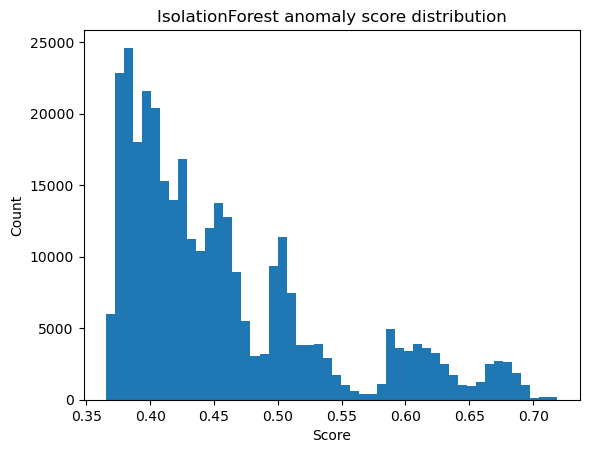

In [ ]:
dv.plot_anomaly_score_distribution(models["IsolationForest"], X_train_reduced)

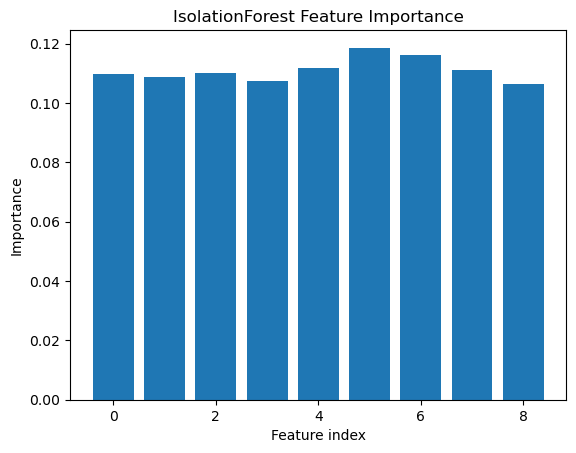

In [ ]:
dv.feature_importnace_anomaly(models["IsolationForest"])

In [ ]:
ad.get_anomaly_scores(models, X_val_reduced)

{'IsolationForest': array([0.02573945, 0.02049098, 0.01363182, ..., 0.02812848, 0.02812848,
        0.02447791], shape=(1581,)),
 'OneClassSVM': array([-42116.21994956, -43235.98497248, -43936.28015966, ...,
        -39882.04438207, -39336.28347601, -39871.59662341], shape=(1581,)),
 'EllipticEnvelope': array([35565.67733492, 35580.79259474, 35579.01713451, ...,
        35673.23173626, 35668.90512946, 35656.07219467], shape=(1581,))}

In [ ]:
results = ad.predict_anomalies(models, X_val_reduced)
results

Predicting anomalies with IsolationForest...
Anomalies predicted with IsolationForest.
Anomaly counts:
(array([0, 1]), array([1075,  506]))
Predicting anomalies with OneClassSVM...
Anomalies predicted with OneClassSVM.
Anomaly counts:
(array([1]), array([1581]))
Predicting anomalies with EllipticEnvelope...
Anomalies predicted with EllipticEnvelope.
Anomaly counts:
(array([0, 1]), array([1531,   50]))
Anomaly prediction completed for all models.


{'IsolationForest': array([0, 0, 0, ..., 0, 0, 0], shape=(1581,)),
 'OneClassSVM': array([1, 1, 1, ..., 1, 1, 1], shape=(1581,)),
 'EllipticEnvelope': array([0, 0, 0, ..., 0, 0, 0], shape=(1581,))}

In [ ]:
predictions = results["IsolationForest"]

translated = np.where(predictions == 1, 0, 1)

Text(0.5, 1.0, 'Confusion Matrix')

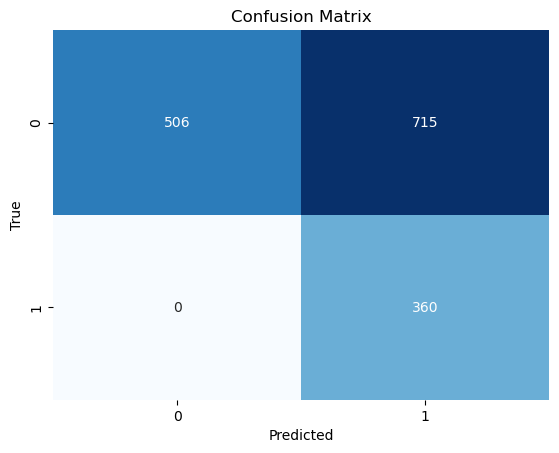

In [ ]:
dv.plot_confusion_matrix(y_val, translated)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, translated)
recall = recall_score(y_val, translated)
f1 = f1_score(y_val, translated)

precision, recall, f1


(0.33488372093023255, 1.0, 0.5017421602787456)

In [ ]:
# show anomaly counts for each model
for model_name, preds in results.items():
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Anomaly counts for {model_name}: {dict(zip(unique, counts))}")

Anomaly counts for IsolationForest: {np.int64(0): np.int64(1075), np.int64(1): np.int64(506)}
Anomaly counts for OneClassSVM: {np.int64(1): np.int64(1581)}
Anomaly counts for EllipticEnvelope: {np.int64(0): np.int64(1531), np.int64(1): np.int64(50)}


Predicting anomalies with IsolationForest...
Anomalies predicted with IsolationForest.
Anomaly counts:
(array([0, 1]), array([327524,   3804]))
Anomaly prediction completed for all models.
f1 Score on Training + Validation Set for Isolation forest: 0.26980589105737807


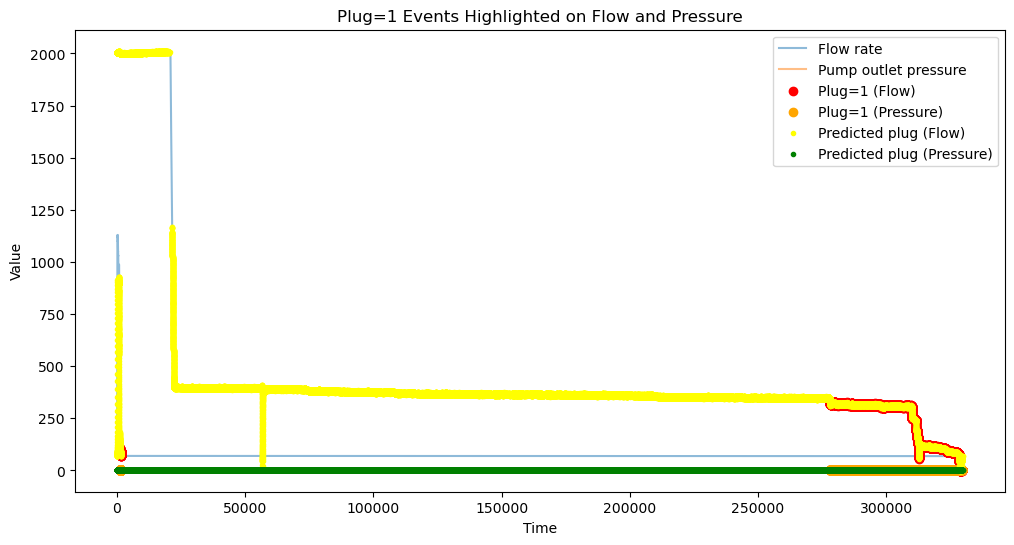

In [ ]:
import numpy as np 
from sklearn.metrics import f1_score


results = ad.predict_anomalies({"IsolationForest": models['IsolationForest']}, X_train_val_reduced)
translated = np.where(results['IsolationForest'] == 1, 0, 1)

f1 = f1_score(y_train_val, translated)
print("f1 Score on Training + Validation Set for Isolation forest:", f1)

dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

In [ ]:
isolation_forest_param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_samples': [0.5, 0.7, 1.0],
        'max_features': [0.5, 0.7, 1.0],
        'contamination': [0.01, 0.05, 0.1]
    }

best_isolation_forest_model, best_isolation_forest_params, best_isolation_forest_score = ad.hyperparameter_search(models["IsolationForest"], isolation_forest_param_grid, X_train_val_reduced)

Starting hyperparameter search for IsolationForest...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, 

Hyperparameter search completed.
Best parameters found: {'n_estimators': 50, 'max_samples': 1.0, 'max_features': 0.7, 'contamination': 0.1}
Best cross-validation F1 Score: nan


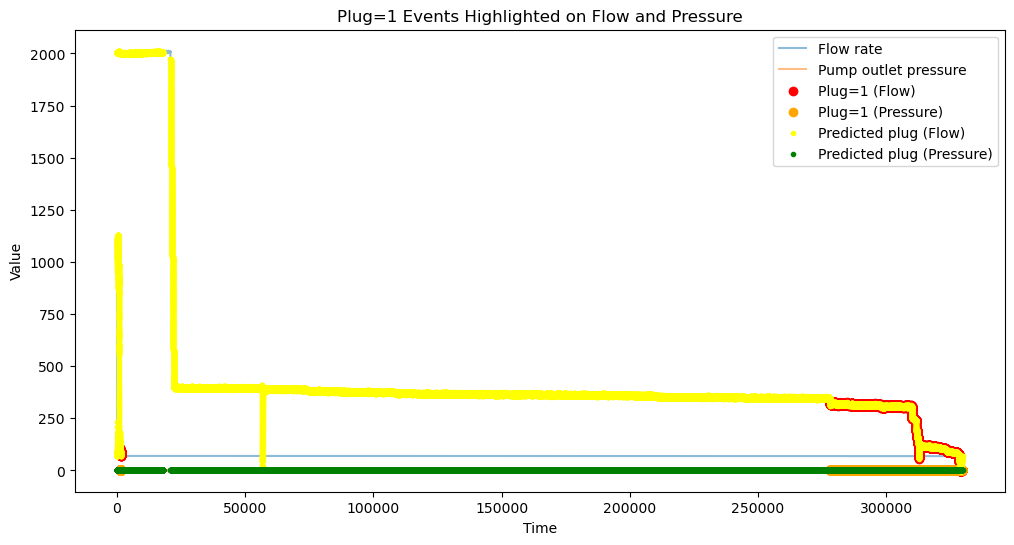

In [ ]:
best_isolation_forest_model, best_isolation_forest_params, best_isolation_forest_score
dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

Predicting anomalies with OneClassSVM...
Anomalies predicted with OneClassSVM.
Anomaly counts:
(array([0, 1]), array([164874, 166454]))
Anomaly prediction completed for all models.
f1 Score on Training + Validation Set for OneClassSVM: 0.0


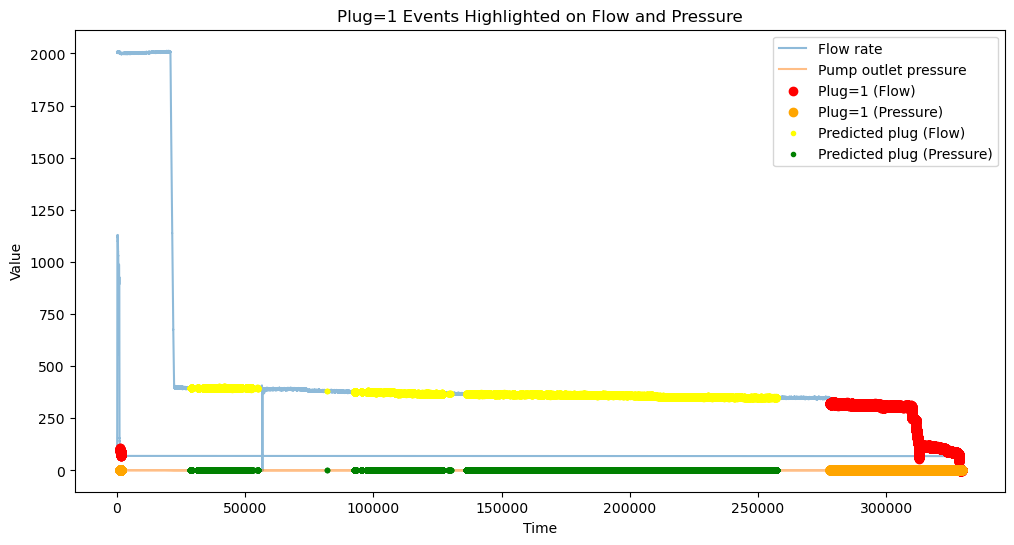

In [ ]:
import numpy as np 
from sklearn.metrics import f1_score


results = ad.predict_anomalies({"OneClassSVM": models['OneClassSVM']}, X_train_val_reduced)
translated = np.where(results['OneClassSVM'] == 1, 0, 1)

f1 = f1_score(y_train_val, translated)
print("f1 Score on Training + Validation Set for OneClassSVM:", f1)

dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

Predicting anomalies with EllipticEnvelope...
Anomalies predicted with EllipticEnvelope.
Anomaly counts:
(array([0, 1]), array([327980,   3348]))
Anomaly prediction completed for all models.
f1 Score on Training + Validation Set for EllipticEnvelope: 0.27184757609208243


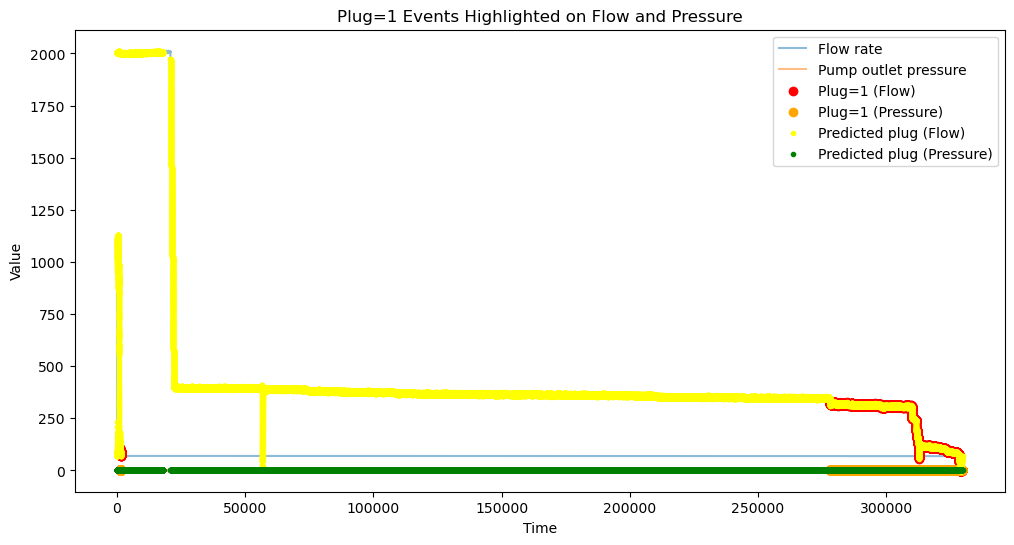

In [ ]:
import numpy as np 
from sklearn.metrics import f1_score


results = ad.predict_anomalies({"EllipticEnvelope": models['EllipticEnvelope']}, X_train_val_reduced)
translated = np.where(results['EllipticEnvelope'] == 1, 0, 1)

f1 = f1_score(y_train_val, translated)
print("f1 Score on Training + Validation Set for EllipticEnvelope:", f1)

dv.visualize_predicted_vs_true(X_train_val_unscaled, translated)

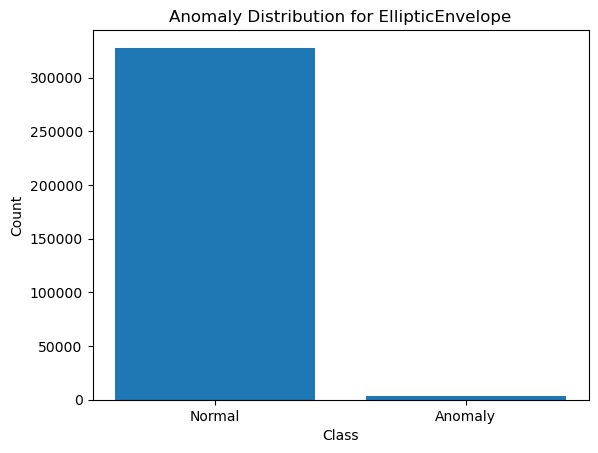

In [ ]:
# Show distribution of predicted anomalies for each model
for model_name, preds in results.items():
    dv.plot_anomaly_distribution(preds, model_name)



# Supervised

## Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [ ]:
y_train.value_counts(normalize=True)

Plug_future
0.0    0.844629
1.0    0.155371
Name: proportion, dtype: float64

In [ ]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val, verbose_level=2, visualize=False)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...
Params: {'n_estimators': 100, 'max_depth': 10} | Validation F1 Score = 0.7164
Params: {'n_estimators': 100, 'max_depth': 20} | Validation F1 Score = 0.7164
Params: {'n_estimators': 200, 'max_depth': 10} | Validation F1 Score = 0.7164
Params: {'n_estimators': 200, 'max_depth': 20} | Validation F1 Score = 0.7193

✅ Best parameters found: {'n_estimators': 200, 'max_depth': 20}
Best validation F1 Score: 0.7193
Best Random Forest model with params: {'n_estimators': 200, 'max_depth': 20} achieved validation F1 Score: 0.7193

🔍 Tuning Logistic Regression...
Searching over 4 hyperparameter combinations...
Params: {'C': 1.0, 'solver': 'lbfgs'} | Validation F1 Score = 0.6857
Params: {'C': 1.0, 'solver': 'liblinear'} | Validation F1 Score = 0.6963
Params: {'C': 0.5, 'solver': 'lbfgs'} | Validation F1 Score = 0.6916
Params: {'C': 0.5, 'solver': 'liblinear'} | Validation F1 Score = 0.6936

✅ Best parameters found: {'C': 1.0,

TypeError: object of type 'NoneType' has no len()

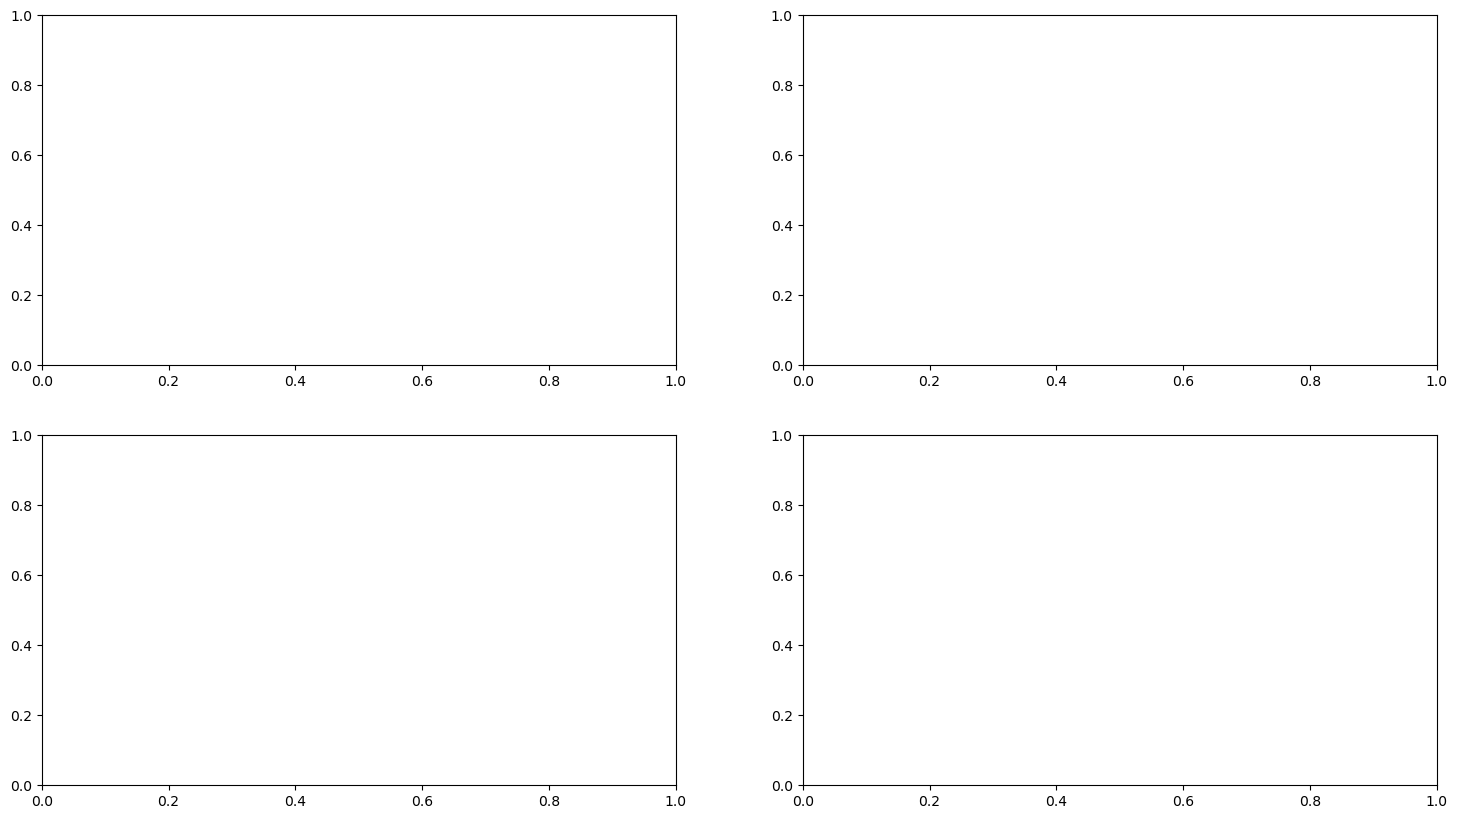

In [ ]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_val)

dv.plot_all(best_model, X_val, y_val, train_sizes, train_scores, val_scores)

⚙️ Features descaled using StandardScaler inverse transform


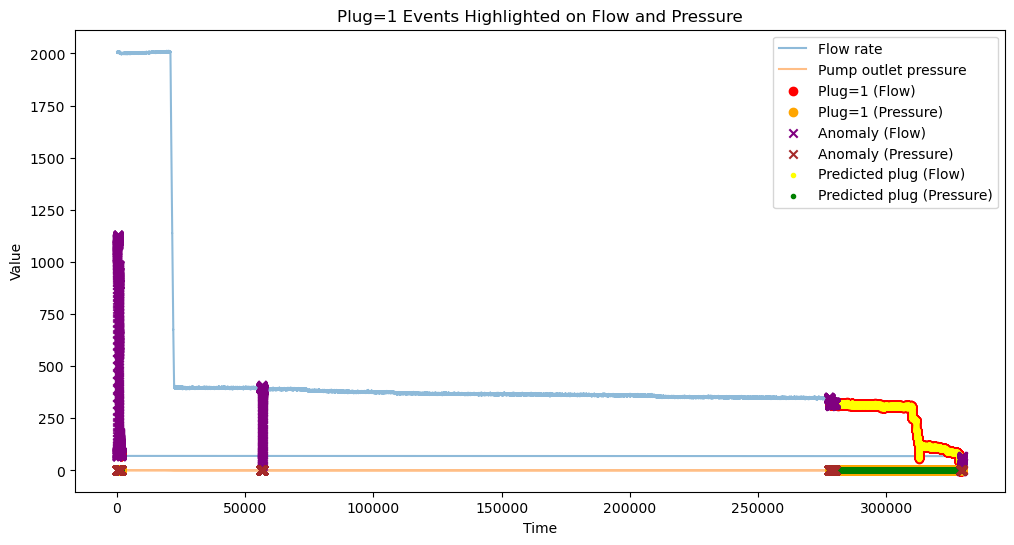

In [ ]:
X_all = pd.concat([X_train, X_val]) #TODO: here we use with all the features, when the model was trained with reduced features
y_all = pd.concat([y_train, y_val])

y_pred = best_model.predict(X_all)

X_all_unscaled_part = dp.descale_features(X_all)

X_all_unscaled = X_all_unscaled_part.copy()
X_all_unscaled['Plug'] = y_all

dv.visualize_predicted_vs_true(X_all_unscaled, y_pred, anomalies=True)


## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [ ]:
print(f"Evaluating best model ({best_model.__class__.__name__}) on test set:")
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
y_pred = dm.evaluate_model_on_test(best_model, X_test, y_test)

Evaluating best model (MLPClassifier) on test set:
[1. 1. 1. ... 1. 1. 1.]
Test set results:
              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000         0
         1.0      1.000     0.999     0.999      1582

    accuracy                          0.999      1582
   macro avg      0.500     0.499     0.500      1582
weighted avg      1.000     0.999     0.999      1582

F1 Score: 0.9993674889310563


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save best model


In [ ]:
dm.save_model(best_model, "../models/best_pipeline.joblib")

Saved model to ../models/best_pipeline.joblib


### Visualize performance

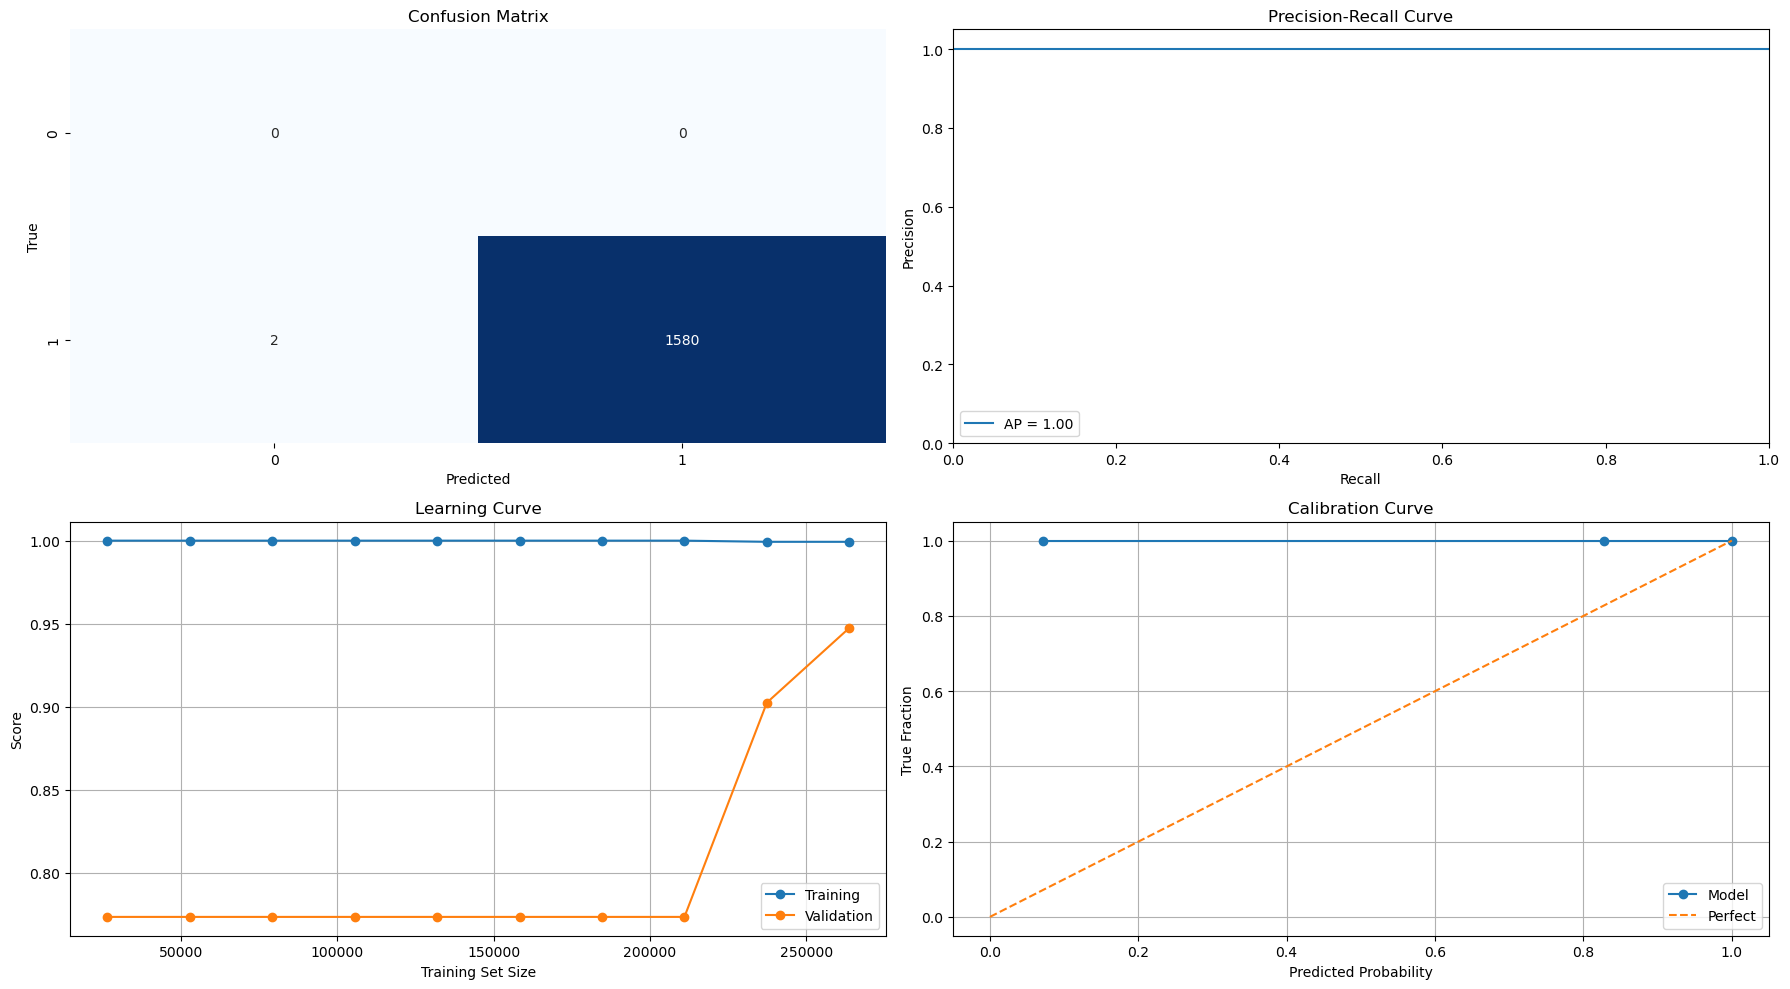

In [ ]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_test)

dv.plot_all(best_model, X_test, y_test, train_sizes, train_scores, val_scores)